In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False
import warnings
# 忽略所有警告
warnings.filterwarnings("ignore")

path = r"2025-8-2公众号Python机器学习AI.xlsx"
df = pd.read_excel(path)
df

,infP,infC,infAc,infpro,infS,MLSS,MLVSS,VSS/TSS,volumn,ana-time,pH,T,salinity,SR
0,12.57,70.32,70.32,0.00,166.17,6.15,3.07,0.50,10.0,6.0,8.0,22,0.09,34.45
1,9.29,67.40,67.40,0.00,135.80,8.48,4.82,0.57,20.0,12.0,7.4,30,0.70,8.22
2,9.04,67.40,67.40,0.00,135.80,8.67,5.94,0.69,20.0,12.0,7.4,30,0.70,18.67
3,10.36,85.00,52.01,32.99,155.14,9.60,6.91,0.72,0.5,0.3,7.5,30,0.70,3.06
4,11.21,74.84,74.84,0.00,209.74,4.83,2.38,0.49,10.0,6.0,8.0,22,0.09,70.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550,6.54,52.60,52.60,0.00,117.24,3.10,2.40,0.77,4.0,2.0,7.4,20,0.05,11.03
551,9.88,74.70,74.70,0.00,224.10,7.70,4.60,0.60,20.0,6.0,7.5,30,1.00,28.27
552,11.43,67.74,67.74,0.00,190.81,5.41,2.79,0.51,10.0,6.0,8.0,22,0.09,54.24
553,9.62,78.40,78.40,0.00,235.19,7.70,4.60,0.60,20.0,6.0,7.5,30,1.00,21.79


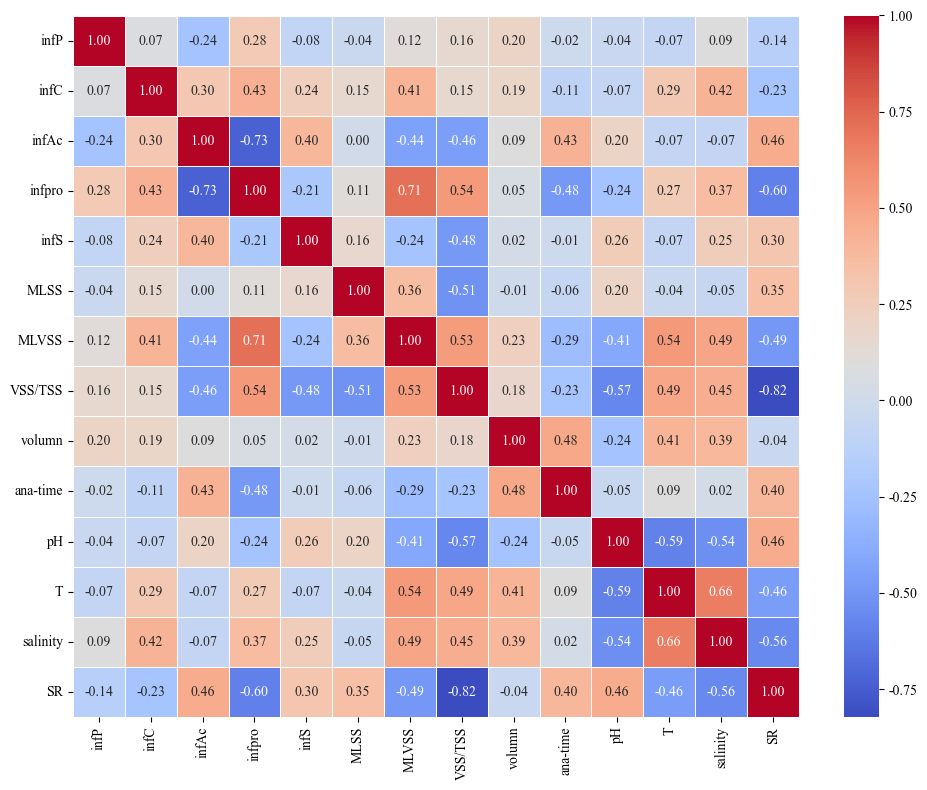

In [19]:
import seaborn as sns
# 计算相关系数矩阵
corr_matrix = df.corr()
# 绘制相关系数热力图
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
# annot=True：在每个单元格中显示数值 cmap='coolwarm'：使用"coolwarm"颜色映射（冷暖色调） linewidths=0.5：设置网格线宽度为0.5
plt.savefig("corr_matrix.pdf", format='pdf', bbox_inches='tight', dpi=1200)
plt.tight_layout()
plt.show()

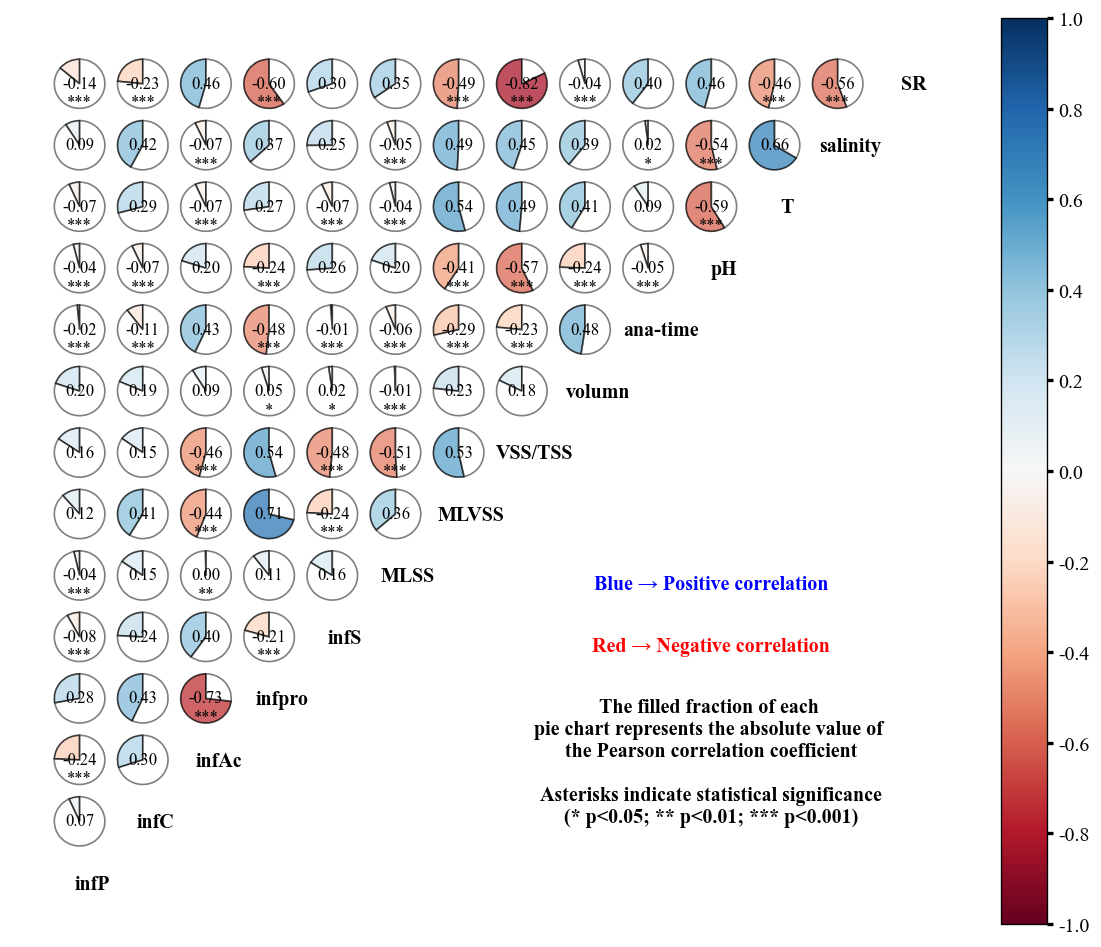

In [20]:
from matplotlib.patches import Wedge

corr = df.corr()
p_values = df.corr(method="pearson")  

# 创建图形
fig, ax = plt.subplots(figsize=(10, 8), dpi=120)
cmap = plt.cm.RdBu  # 使用红蓝色
norm = plt.Normalize(vmin=-1, vmax=1)

# 循环绘制饼图（下三角部分）和数值（上三角部分）
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        if i >= j:
            ax.scatter(i, j, s=1, color='white')  # 不显示任何内容，保持空白
        else:
            coeff = corr.iloc[i, j]  # 相关系数
            abs_coeff = np.abs(coeff)  # 相关系数的绝对值

            # 设置饼图的起始角度和结束角度（有色部分表示相关性大小）
            start_angle = 90  # 起始角度
            end_angle = 90 + abs_coeff * 360  # 结束角度

            # 计算中心点位置
            x, y = i, j

            # 添加扇形（饼图效果）
            wedge = Wedge(center=(x, y), r=0.4, theta1=start_angle, theta2=end_angle,
                          facecolor=cmap(norm(coeff)), edgecolor='black', alpha=0.75)
            ax.add_patch(wedge)

            # 填充背景（无色部分）
            bg_wedge = Wedge(center=(x, y), r=0.4, theta1=end_angle, theta2=start_angle + 360,
                             facecolor='white', edgecolor='black', alpha=0.5)
            ax.add_patch(bg_wedge)

            # 设置字体颜色，根据相关系数的绝对值选择颜色
            if abs_coeff > 0.85:
                font_color = 'white'  # 相关系数绝对值大于0.85时，字体颜色为白色
            else:
                font_color = 'black'  # 否则为黑色

            # 在每个饼图的正中央位置添加相关系数值
            ax.text(x, y, f'{coeff:.2f}', ha='center', va='center', fontsize=10, color=font_color)

            # 获取显著性水平
            p_value = p_values.iloc[i, j]
            if p_value < 0.001:
                sig = '***'
            elif p_value < 0.01:
                sig = '**'
            elif p_value < 0.05:
                sig = '*'
            else:
                sig = ''  # 如果不显著，则不显示

            # 在相关系数下方添加显著性符号
            ax.text(x, y - 0.3, sig, ha='center', va='center', fontsize=10, color=font_color)

# 设置坐标轴标签
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=10)# ha='right'是右对齐的意思
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=10)

# 添加颜色条
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # 仅用于显示颜色条
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', ticks=[-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])
# sm：传入之前创建的ScalarMappable对象
# ax=ax：指定颜色条关联的坐标轴
# orientation='vertical'：设置颜色条为垂直方向
# ticks=[...]：手动指定颜色条上显示的刻度值，从-1到1，间隔为0.2，这样可以清晰地显示相关系数的范围（相关系数的取值范围是-1到1）

# 设置颜色条的细长样式
cbar.ax.tick_params(width=0.01)  # 设置颜色条刻度线的宽度

# 调整颜色条刻度标签的字体大小和加粗
cbar.ax.tick_params(labelsize=12, width=2)  # 增大字体并加粗刻度线
# 关闭坐标轴的边框
for spine in ax.spines.values():
    spine.set_visible(False)
# ax.spines: 在 Matplotlib 中，spines 指的是包围图表区域的四条边框线（上、下、左、右）。它是一个字典，键是'top', 'bottom', 'left', 'right'
# .values(): 获取这四条边框线对应的对象
# spine.set_visible(False): 将这条边框线设置为不可见

# 关闭x轴和y轴的刻度与标签
ax.set_xticks([])  # 关闭x轴刻度 xticks 和 yticks 指的是坐标轴上的刻度标记（就是那些小短线）
ax.set_yticks([])  # 关闭y轴刻度
ax.set_xticklabels([])  # 关闭x轴标签
ax.set_yticklabels([])  # 关闭y轴标签
for i in range(len(corr.columns)):
    ax.text(i+0.2, i-0.02, df.columns[i], ha='center', va='center', fontsize=12, color='black', fontweight='bold')
# **`i+0.2, i-0.02`**: 这是文本放置的 **X 和 Y 坐标**。`i` 同时用在 X 和 Y 上，意味着文本是沿着图表的**对角线**排列的。
# # `+0.2` 和 `-0.02` 是微小的偏移量，用于精确调整文本位置，使其看起来更美观。
# **`df.columns[i]`**: 这是要**显示的具体文本内容**
ax.text(10, 5, "Blue → Positive correlation", ha='center', va='top', fontsize=12, color='blue', fontweight='bold')
#  在 (10, 5) 位置用蓝色写下 "Blue → Positive correlation"，解释了图中蓝色的含义
ax.text(10, 4, "Red → Negative correlation", ha='center', va='top', fontsize=12, color='red', fontweight='bold')
ax.text(10, 3, "The filled fraction of each \npie chart represents the absolute value of \nthe Pearson correlation coefficient\n\nAsterisks indicate statistical significance\n(* p<0.05; ** p<0.01; *** p<0.001)",
        ha='center', va='top', fontsize=12, color='black', fontweight='bold', wrap=True)
plt.savefig("corr.pdf", format='pdf', bbox_inches='tight', dpi=1200)
plt.tight_layout()
plt.show()


In [21]:
from sklearn.model_selection import train_test_split

# 划分特征和目标变量
X = df.drop(['SR'], axis=1)  # 特征
y = df['SR']  # 目标变量

# 划分训练集和测试集，测试集占 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

from sklearn.preprocessing import StandardScaler
import pickle 

# 初始化标准化器
scaler = StandardScaler()

# 标准化训练集
X_train_scaled = scaler.fit_transform(X_train)

# 用相同参数标准化测试集
X_test_scaled = scaler.transform(X_test)
# 我们使用在训练集上计算出的相同均值和标准差参数来标准化测试集

In [22]:
import xgboost as xgb

model_xgb = xgb.XGBRegressor(random_state=42)
model_xgb.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [23]:
import shap
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)
explainer = shap.TreeExplainer(model_xgb)
# 计算shap值为Explanation格式
shap_values_Explanation = explainer(X_test_scaled_df)

In [27]:
plt.figure(figsize=(10, 5), dpi=1200)
shap.plots.bar(shap_values_Explanation,  max_display=13, show=False)
plt.savefig("SHAP_Explanation Sorted Feature Importance.pdf", format='pdf',bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
# 计算 clustering 结果和 shap_values_Explanation
clustering = shap.utils.hclust(X_test_scaled, y_test)
plt.figure(figsize=(10, 5), dpi=1200)
shap.plots.bar(shap_values_Explanation, 
               clustering=clustering, # clustering_cutoff=0.8：设置聚类切割阈值为0.8，决定哪些特征应该被分组在一起
               clustering_cutoff=0.8, 
               show=False, max_display=13) 
plt.savefig("SHAP_Explanation_with_Clustering.pdf", format='pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

“聚类切割阈值”是什么呢？  
它就是CEO制定的一条“部门独立性”的规定线。  
CEO说：“为了保持团队的专注和高效，我要画一条线。任何跨越这条线的合并，我都认为是不必要的，应该保持为独立的部门。”  
理解“切割”的过程  
在您的图中，这条规定线就是 Clustering cutoff = 0.8 那条垂直的虚线。  
现在，我们来当一次CEO，用这条线来“切割”我们的组织架构图：  
从右向左看：我们从最右边（代表整个公司）往左看。  
遇到合并点就检查：我们会遇到很多团队或部门的合并点（那些水平线）。  
应用规则：  
如果一个合并点在规定线（0.8）的右边，意味着这次合并的两个团队差异太大了（距离太远），不符合“高效专注”的原则。于是我们**“切断”**这次合并。这两个团队就各自成为独立的部门。  
如果一个合并点在规定线（0.8）的左边，意味着这次合并的两个小组合并得非常紧密，工作内容高度相似。这次合并是允许的，它们可以继续作为一个整体存在。  

核心目标：为什么要优化特征和减少冗余？  
想象一下，您是一位教练，要组建一支篮球队（训练一个机器学习模型）。您有很多候选队员（特征）。  
优化特征：您想选出那些真正能得分、能防守、对胜利贡献最大的“明星球员”（高重要性特征）。  
减少冗余：您发现有三个球员，身高、技术、风格几乎一模一样，让他们同时上场并不能带来1+1+1=3的效果，反而可能因为位置重叠而互相干扰。您只需要留下他们中综合表现最好的一个（消除高度相关的冗余特征）。  
在机器学习中，特征过多或冗余会带来几个问题：  
过拟合（Overfitting）: 模型学到了太多训练数据中的噪音和细节，导致在新的、未见过的数据上表现很差。就像一支球队只擅长打一种战术，遇到新对手就输了。  
计算成本高: 特征越多，模型训练和预测所需的时间就越长，消耗的计算资源也越多。  
模型解释性差: 一两百个特征的模型，你很难搞清楚它到底是怎么做决策的。特征越少越精，模型就越像一个“白盒子”。  
所以，我们的目标就是：用最少、最关键的特征，构建一个性能同样好（甚至更好）、速度更快、更容易理解的模型。  

两大工具：各自的职责和局限  
为了实现这个目标，您的课程介绍了两种强大的工具：Pearson相关分析和SHAP。它们就像两位专业的球探，各有专长。  
1. 球探A：Pearson相关分析 (专门寻找“关系户”)  
它的工作是什么？  
Pearson相关系数（通常用 'r' 表示）专门用来衡量两个特征之间线性关系的强度和方向。  
r 接近 +1：一个特征增加时，另一个特征也倾向于线性增加（比如：身高和臂展）。  
r 接近 -1：一个特征增加时，另一个特征倾向于线性减少。  
r 接近 0：两个特征之间没有明显的线性关系。  
它如何帮助减少冗余？  
如果两个输入特征的Pearson相关系数的绝对值非常高（例如大于0.9），就意味着它们携带的信息几乎是一样的。当一个变化时，另一个也以几乎固定的比例变化。因此，它们是高度冗余的。我们可以放心地从模型中移除其中一个，而不会损失太多信息。  
它的局限性是什么？  
这是最关键的一点！Pearson相关分析有两个致命弱点：  
它只能看到线性关系。对于U型、环形等复杂的非线性关系，它会无能为力，可能会给出接近0的相关性，让你误以为它们不相关。  
它只关心特征与特征之间的关系 (X vs X)，它完全不知道哪个特征对最终的预测目标 (Y) 更重要。它可能会告诉你球员A和球员B技术相似，但它不知道A和B到底是不是得分主力。  
2. 球探B：SHAP评估特征重要性 (专门寻找“MVP”)  
它的工作是什么？  
SHAP是一种更高级、更全面的工具。它不关心特征之间的关系，而是直接评估每个特征对模型最终预测结果的贡献度。  
您提供的那张图就是SHAP的工作成果。条形越长，代表该特征对模型的预测结果影响越大，是当之无愧的“MVP”（最有价值球员）或核心主力。  
例如，您的图显示 VSS/TSS 是最重要的特征，它的SHAP值远超其他特征。  
它如何帮助优化特征？  
SHAP直接给出了一个基于模型贡献度的“英雄榜”。我们可以优先保留排名靠前的特征，并考虑剔除那些排名垫底、几乎没有贡献的特征（比如图中的 T 和 salinity）。  
它的局限性是什么？  
SHAP本身主要关注“贡献度”，它不会直接告诉你“A和B的功能很像，可以去掉一个”。它可能会告诉你A和B都挺重要的，但如果A和B高度相关，保留两个可能就是冗余的。  

强强联合：完美的特征筛选策略  
现在，我们把两位球探的报告结合起来，制定一个完美的选人策略。这就是您课程的核心思想。  
  
步骤 1：用 SHAP 找出所有有价值的球员 (评估重要性)  
首先，我们用所有特征训练一个初始模型。然后，运行SHAP分析（就像您生成那张图一样），得到所有特征的重要性排名。  
产出：一张特征“英雄榜”。我们知道了谁是明星球员(VSS/TSS)，谁是主力(ana-time, infS)，谁是替补，谁是几乎不上场的“饮水机管理员”(T, salinity)。  
初步决策：我们可以先划定一个范围，比如只在SHAP重要性排名前20的特征里进行下一步筛选。  

步骤 2：在有价值的球员中，用 Pearson 找出功能重叠的人 (识别冗余)  
现在，我们只关注那些在SHAP榜单上表现不错的特征。我们计算这些重要特征之间的Pearson相关系数矩阵。  
产出：一张相关系数表，显示了重要球员两两之间的“相似度”。  
发现问题：我们可能会发现，infP 和 infC 的相关系数高达 0.92。这意味着这两位球员技术特点高度相似，是“关系户”。  

步骤 3：结合两份报告，做出最终的明智决策 (优化和去冗余)  
这是最关键的一步。当我们发现一对高度相关的特征时（例如 infP 和 infC），我们该去掉谁呢？  
错误的做法：随便去掉一个。  
正确的做法：回到SHAP的“英雄榜”上去查！  
在您的图中，infC的SHAP值是+1.75，而infP的SHAP值是+1.67。  
决策：虽然两者都很重要且高度相关，但infC对模型的贡献度略高。因此，我们应该保留 infC，移除 infP。  
通过这个流程，我们完美地实现了目标：  
SHAP确保了我们留下的都是对模型有用的特征（不会错杀好人）。  
Pearson帮助我们识别出那些功能重复的特征。  
再结合SHAP的重要性，确保我们在“二选一”时，留下了那个贡献更大的特征。  
最终，我们就得到了一套精简、高效、不冗余的“黄金特征组合”，用来训练最终的模型。  